# Testing Plots


In [37]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import gaussian_kde
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d import Axes3D


In [21]:
# change here directories 
csv_dir = '../../fasta_files/cassava/hosts/tme7_1/EastAf/merged_gc.csv'
outputs_dir = '../../fasta_files/cassava/hosts/tme7_1/EastAf/results/'

# load CSV 
df = pd.read_csv(
    csv_dir,
    header=None,
    names=["genome_idx", "position", "raw", "gc_pct", "kmer_len"]
)

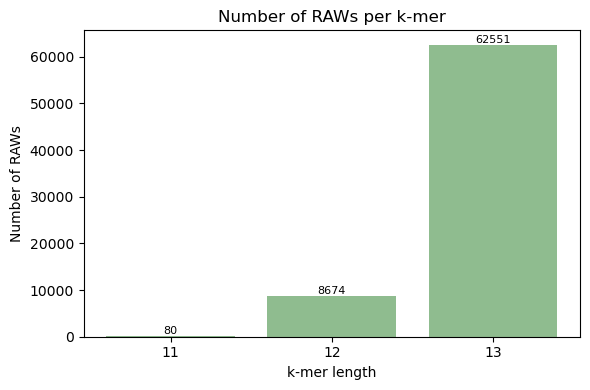

In [22]:

# Count number of raws per k-mer
counts = df["kmer_len"].value_counts().sort_index()

# Plot
plt.figure(figsize=(6,4))
bars = plt.bar(counts.index.astype(str), counts.values, color="darkseagreen")

plt.xlabel("k-mer length")
plt.ylabel("Number of RAWs")
plt.title("Number of RAWs per k-mer")

# Add numbers above bars
for bar, val in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.2, str(val),
            ha='center', va='bottom', fontsize=8)
        
plt.savefig(f"{outputs_dir}/number_raws.png",
            dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

### Trying to recriate article plot

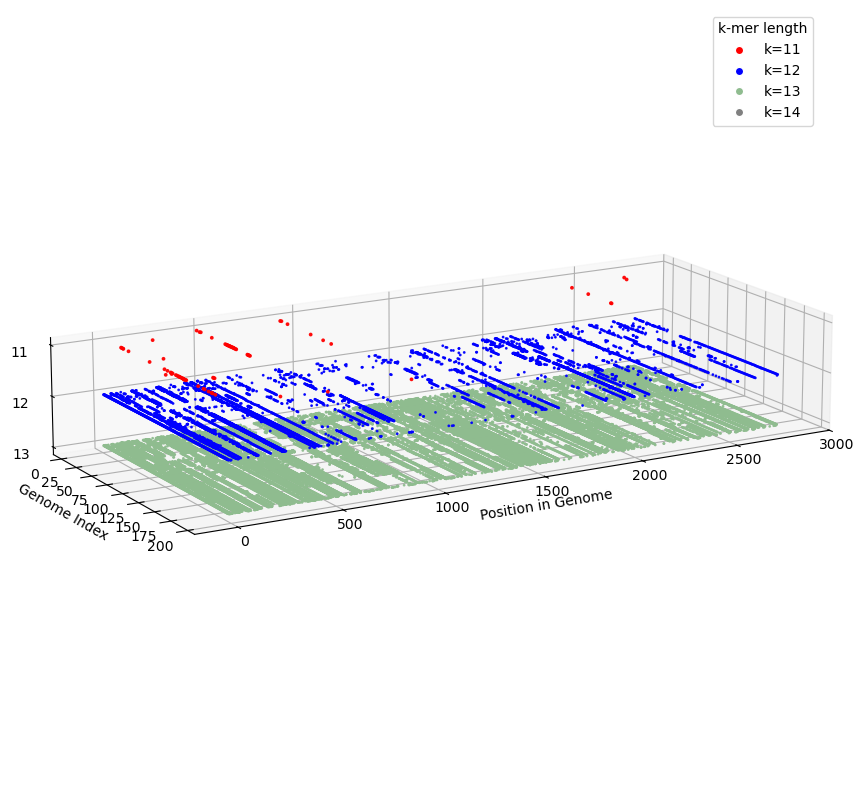

In [23]:
# 2) Extract numeric columns and define colors ----------------------------
# df = df[df["genome_idx"] == 110].copy()
x = df["genome_idx"]
y = df["position"]
z = df["kmer_len"]

colors = df["kmer_len"]
k_colors = {11: "red", 12: "blue", 13: "darkseagreen" , 14: "grey"}
k_sizes = {11: 3, 12: 1, 13: 1, 14: 1}

# 3) 3D scatter -----------------------------------------------------------
fig = plt.figure(figsize=(18,10))
ax = fig.add_subplot(projection="3d")

ax.scatter(
    x, y, z,
    c=colors.map(k_colors),
    s=colors.map(k_sizes),               # dot size
    alpha=0.9,
    depthshade=False
)

ax.zaxis._axinfo['juggled'] = (1, 2, 0)  # moves the Z-axis pane to the left
ax.set_xlabel("Genome Index")
ax.set_ylabel("Position in Genome", labelpad=15)
ax.set_zlabel("k-mer Length")
ax.set_zticks(np.arange(z.min(), z.max() + 1, 1))

ax.set_box_aspect([1.3, 3, 0.5])  # [X, Y, Z] relative scale

ax.grid(True, linestyle=":", alpha=0.6)
ax.view_init(elev=15, azim=-30)

ax.invert_zaxis()

legend_items = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor=c, markersize=6, label=f'k={k}')
    for k, c in k_colors.items()
]
ax.legend(handles=legend_items, loc='upper right', title='k-mer length')

plt.title("3D RAWs Distribution", pad=20)
plt.savefig(f"{outputs_dir}3d_raws_distribution.png", dpi=300)
plt.show()


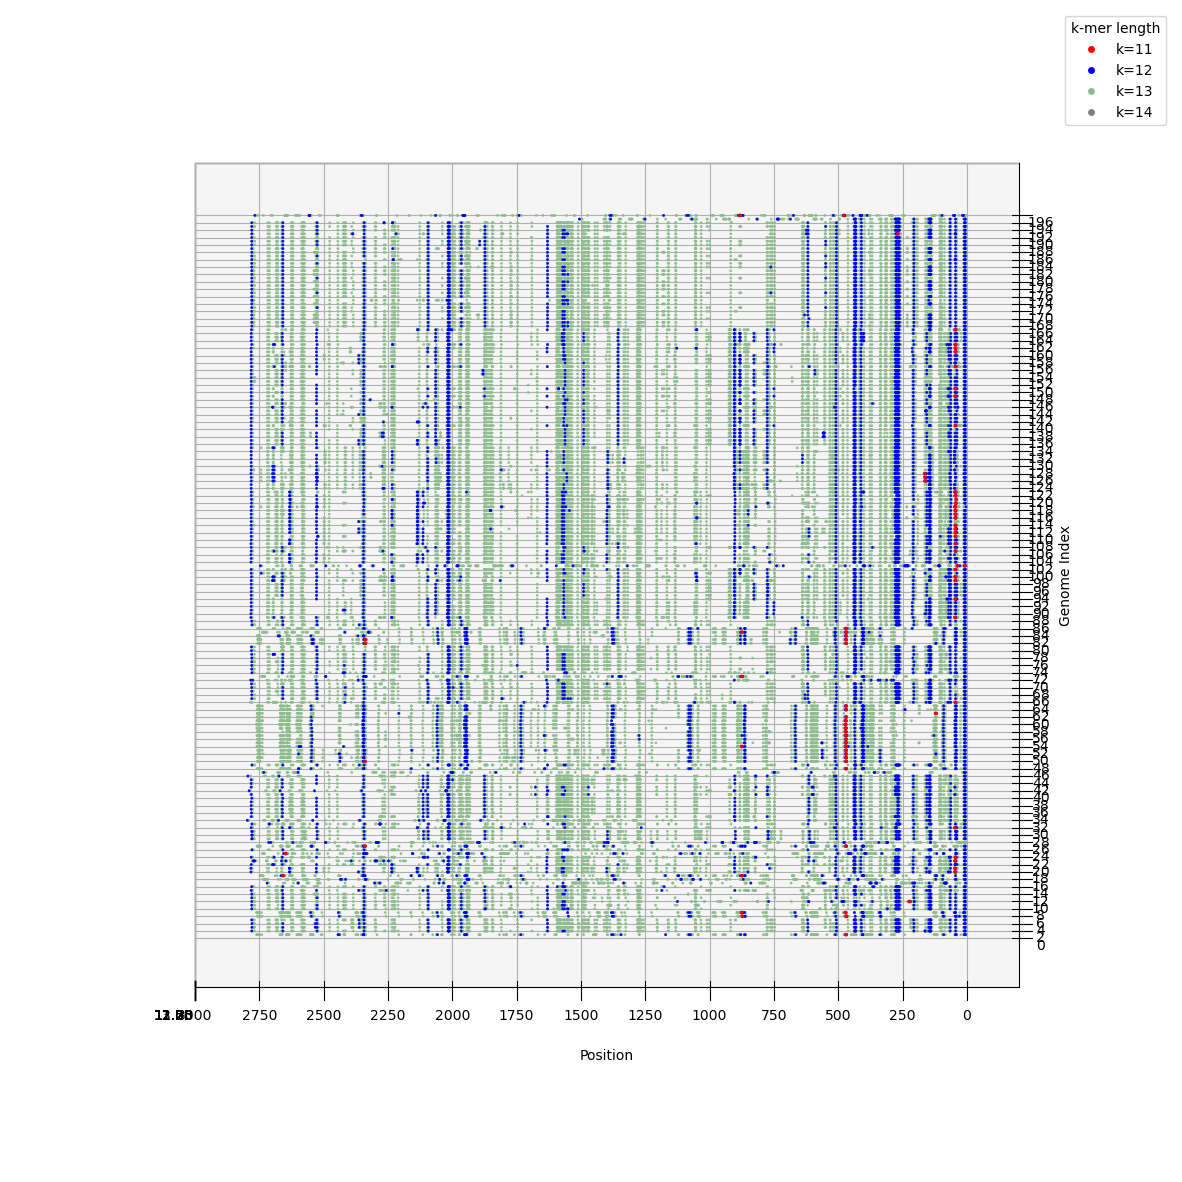

In [24]:
# --- Top-down (up) view ---
fig2 = plt.figure(figsize=(15, 20))
ax3 = fig2.add_subplot(projection="3d")

ax3.scatter(
    x, y, z,
    c=colors.map(k_colors),
    s=colors.map(k_sizes),               # dot size
    alpha=0.9
)
ax3.set_xlabel("Genome Index")
ax3.set_ylabel("Position", labelpad=15)

ax3.set_yticks(np.arange(0, y.max() + 250, 250))
ax3.set_xticks(np.arange(0, x.max() + 2, 2))

ax3.invert_zaxis()

legend_items = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor=c, markersize=6, label=f'k={k}')
    for k, c in k_colors.items()
]
ax3.legend(handles=legend_items, loc='upper right', title='k-mer length')

ax3.view_init(elev=90, azim=180)    # directly above
ax3.set_proj_type('ortho')        # removes perspective (flat view)
ax3.set_box_aspect([3, 3, 1])  # elongate Y
ax3.yaxis.set_label_coords(-0.05, 0.5)

plt.title("3D RAWs Distribution - Top Down View", pad=20)
plt.savefig(f"{outputs_dir}3d_raws_distribution_topdown.png", dpi=300, bbox_inches='tight')
plt.show()

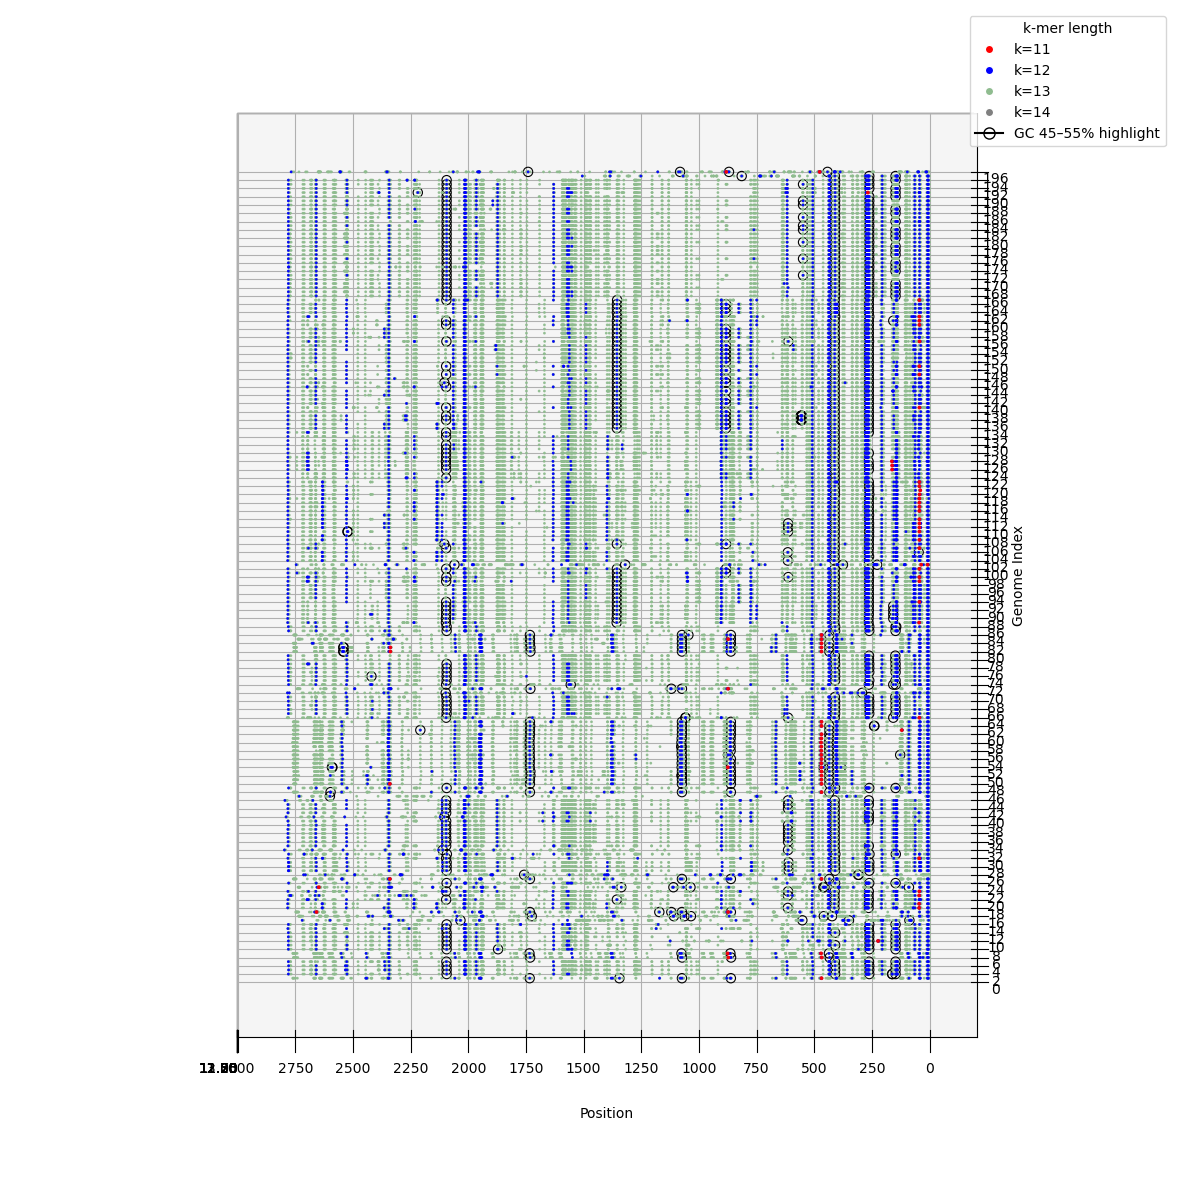

In [36]:
# --- Masks ---
mask_base = df["gc_pct"].between(48, 52)   # base GC% range (for dots)
# mask_highlight = df["gc_pct"].between(48, 52)  # narrower highlight window

# --- Top-down (up) view ---
fig2 = plt.figure(figsize=(15, 35))
ax3 = fig2.add_subplot(projection="3d")

# Base layer (all points)
ax3.scatter(
    x, y, z,
    c=colors.map(k_colors),
    s=colors.map(k_sizes),
    alpha=0.9
)

# Overlay hollow rings (highlight only GC 48–52)
ax3.scatter(
    x[mask_base], y[mask_base], z[mask_base],
    s=45,                     # slightly larger ring than points
    facecolors='none',        # hollow
    edgecolors='black',         # highlight color
    linewidths=0.8,
    zorder=10
)

# --- Axes & style ---
ax3.set_xlabel("Genome Index")
ax3.set_ylabel("Position", labelpad=15)
ax3.set_yticks(np.arange(0, y.max() + 250, 250))
ax3.set_xticks(np.arange(0, x.max() + 2, 2))
ax3.invert_zaxis()
ax3.view_init(elev=90, azim=180)
ax3.set_proj_type('ortho')
ax3.set_box_aspect([5, 4, 1])
ax3.yaxis.set_label_coords(-0.05, 0.5)

legend_items = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor=c,
           markersize=6, label=f'k={k}') for k, c in k_colors.items()
]
legend_items.append(Line2D([0],[0], marker='o', color='black',
                           markerfacecolor='none', markersize=8,
                           label='GC 48–52% highlight'))
ax3.legend(handles=legend_items, loc='upper right', title='k-mer length')

plt.title("3D RAWs Distribution - Top Down View with 48-52 GC% Gap Highlight", pad=20)
plt.savefig(f"{outputs_dir}/3d_raws_distribution_topdown_gc45_55_highlight.png",
            dpi=300, bbox_inches='tight')
plt.show()


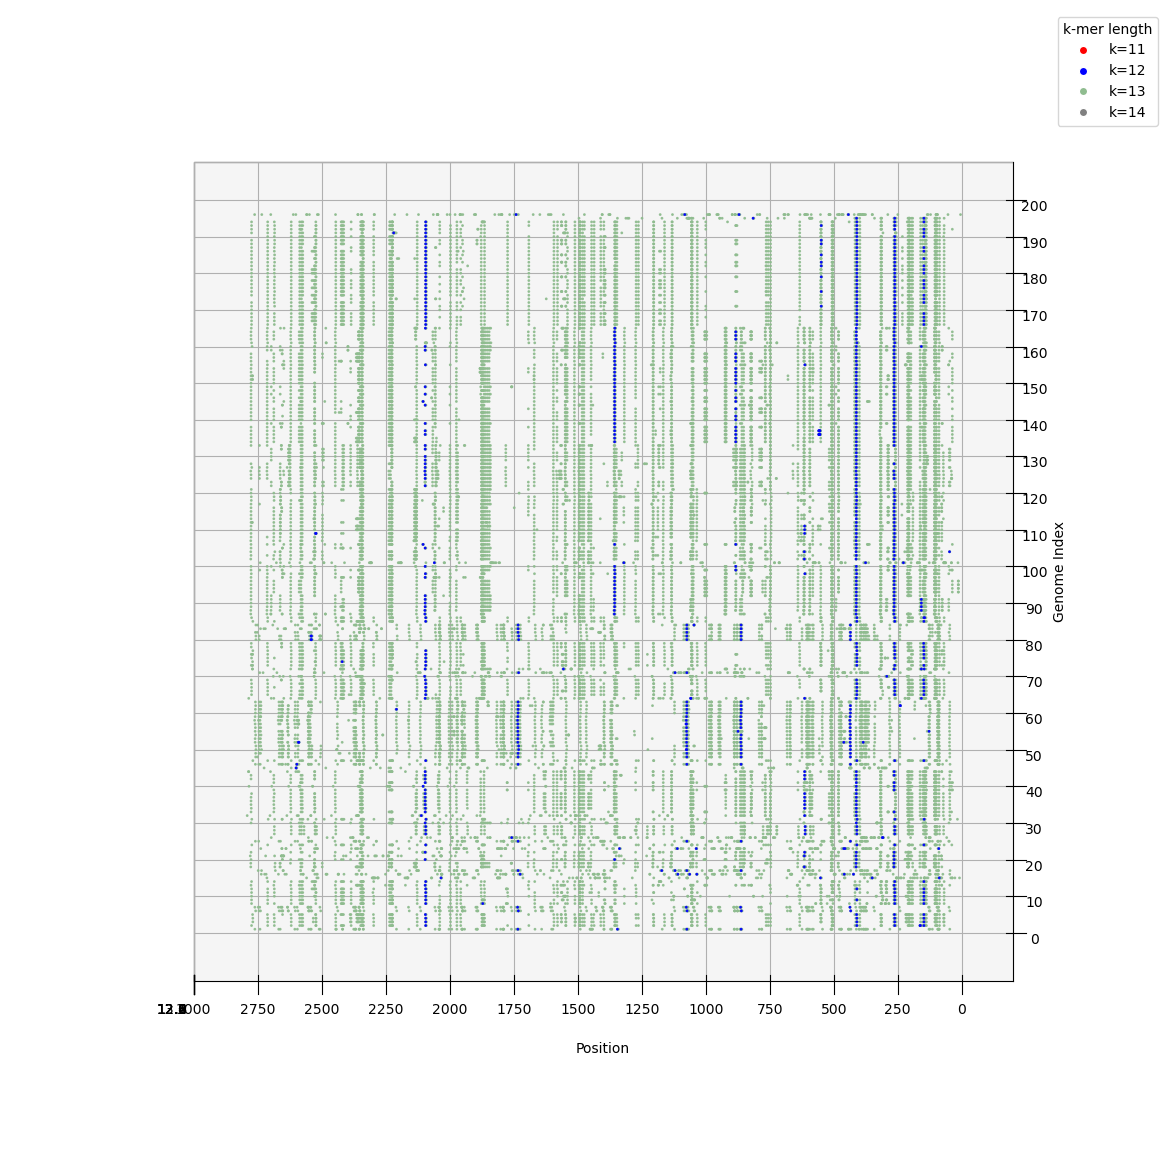

In [26]:
# Build mask first
mask = df["gc_pct"].between(45, 55)

# Prepare arrays only for the masked subset
x_sub = df.loc[mask, "genome_idx"].values
y_sub = df.loc[mask, "position"].values
z_sub = df.loc[mask, "kmer_len"].values

# If you color by k-mer length like before
k_colors = {11: "red", 12: "blue", 13: "darkseagreen", 14: "grey"}
k_sizes  = {11: 3,    12: 1,       13: 1,             14: 1}
colors_sub = pd.Series(z_sub).map(k_colors)
sizes_sub  = pd.Series(z_sub).map(k_sizes)

# --- New top-down (up) view with ONLY GC 45–55% ---
fig2 = plt.figure(figsize=(15, 15))
ax3 = fig2.add_subplot(projection="3d")

ax3.scatter(
    x_sub, y_sub, z_sub,
    c=colors_sub,
    s=sizes_sub,
    alpha=0.9
)

ax3.set_xlabel("Genome Index")
ax3.set_ylabel("Position", labelpad=15)
ax3.set_yticks(np.arange(0, y_sub.max() + 250, 250) if len(y_sub) else [])
ax3.set_xticks(np.arange(0, x_sub.max() + 10, 10) if len(x_sub) else [])

ax3.invert_zaxis()
ax3.view_init(elev=90, azim=180)     # top-down
ax3.set_proj_type('ortho')           # no perspective
ax3.set_box_aspect([3, 3, 1])
ax3.yaxis.set_label_coords(-0.05, 0.5)

legend_items = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor=c, markersize=6, label=f'k={k}')
    for k, c in k_colors.items()
]
ax3.legend(handles=legend_items, loc='upper right', title='k-mer length')

plt.title("3D RAWs Distribution - Top Down View (GC% 45-55% only)", pad=20)
plt.savefig(f"{outputs_dir}/3d_raws_distribution_topdown_gc45_55.png",
            dpi=300, bbox_inches='tight')
plt.show()


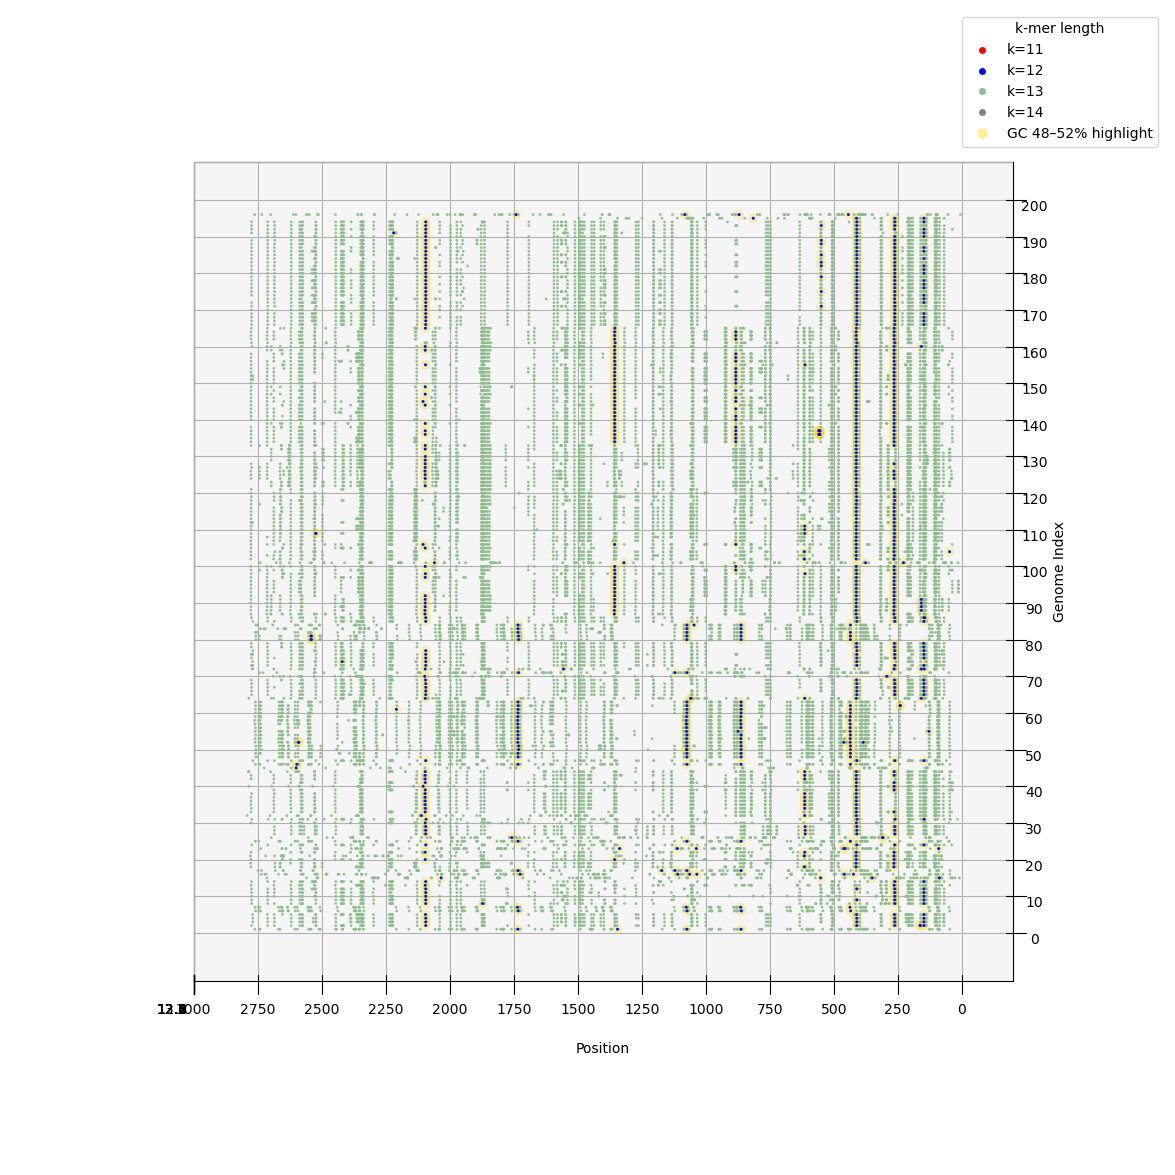

In [27]:
# --- Base mask and subset ---
mask = df["gc_pct"].between(45, 55)
x_sub = df.loc[mask, "genome_idx"].values
y_sub = df.loc[mask, "position"].values
z_sub = df.loc[mask, "kmer_len"].values

# --- Colors and sizes ---
k_colors = {11: "red", 12: "blue", 13: "darkseagreen", 14: "grey"}
k_sizes  = {11: 3,    12: 1,       13: 1,             14: 1}
colors_sub = pd.Series(z_sub).map(k_colors)
sizes_sub  = pd.Series(z_sub).map(k_sizes)

# --- NEW: mask for 48–52% ---
mask_highlight = df["gc_pct"].between(48, 52)
x_high = df.loc[mask_highlight, "genome_idx"].values
y_high = df.loc[mask_highlight, "position"].values
z_high = df.loc[mask_highlight, "kmer_len"].values

# --- Plot ---
fig2 = plt.figure(figsize=(15, 15))
ax3 = fig2.add_subplot(projection="3d")

# 1️⃣ Draw a faint “halo” for the 48–52% points (slightly larger, transparent)
ax3.scatter(
    x_high, y_high, z_high,
    c="gold",  # soft highlight color (you can change it)
    s=50,      # larger than normal dots
    alpha=0.25,
    edgecolors="none"
)

# 2️⃣ Draw your main filtered scatter
ax3.scatter(
    x_sub, y_sub, z_sub,
    c=colors_sub,
    s=sizes_sub,
    alpha=0.9
)

# --- Labels, layout, etc. ---
ax3.set_xlabel("Genome Index")
ax3.set_ylabel("Position", labelpad=15)
ax3.set_yticks(np.arange(0, y_sub.max() + 250, 250) if len(y_sub) else [])
ax3.set_xticks(np.arange(0, x_sub.max() + 10, 10) if len(x_sub) else [])

ax3.invert_zaxis()
ax3.view_init(elev=90, azim=180)
ax3.set_proj_type('ortho')
ax3.set_box_aspect([3, 3, 1])
ax3.yaxis.set_label_coords(-0.05, 0.5)

legend_items = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor=c, markersize=6, label=f'k={k}')
    for k, c in k_colors.items()
]
legend_items.append(Line2D([0],[0], marker='o', color='w', markerfacecolor='gold',
                           markersize=8, alpha=0.4, label='GC 48–52% highlight'))

ax3.legend(handles=legend_items, loc='upper right', title='k-mer length')

plt.title("3D RAWs Distribution - Top Down View (GC% 45-55% only with 48-52% Highlight)", pad=20)
plt.savefig(f"{outputs_dir}/3d_raws_distribution_topdown_gc45_55_highlight.png",
            dpi=300, bbox_inches='tight')
plt.show()


### GC vs K plot

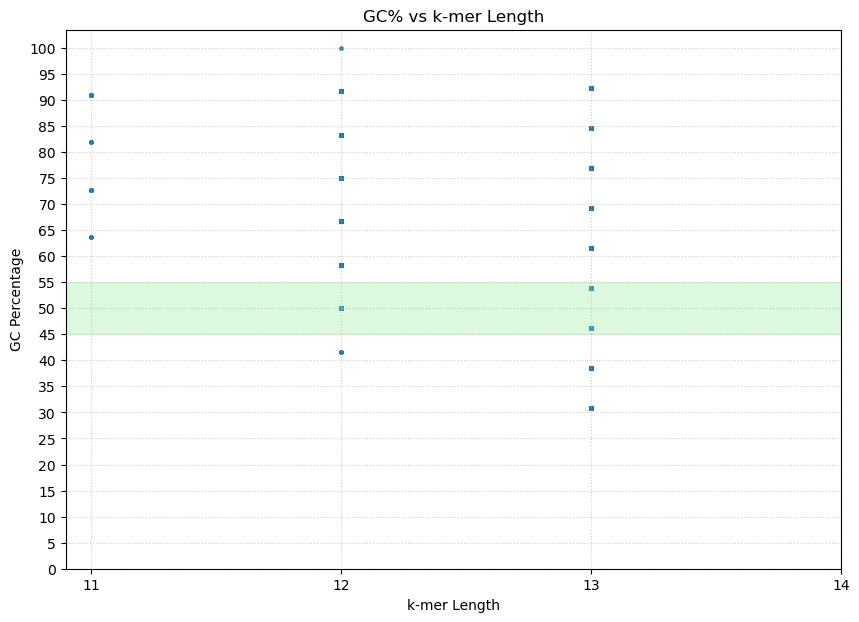

In [28]:
plt.figure(figsize=(10, 7))
plt.scatter(pd.to_numeric(df["kmer_len"]), df["gc_pct"], s=5, alpha=0.7)

plt.xlabel("k-mer Length")
plt.ylabel("GC Percentage")

plt.axhspan(45, 55, color='lightgreen', alpha=0.3)

plt.xticks(np.arange(11, 15, 1))  # from 0% to 100% every 5%
plt.yticks(np.arange(0, 101, 5))  # from 0% to 100% every 5%
plt.grid(True, linestyle=":", alpha=0.6)

plt.title("GC%s vs k-mer Length")
plt.savefig(f"{outputs_dir}gc%_vs_kmer.png", dpi=300, bbox_inches='tight')
plt.show()


In [29]:
# --- Filter raws within GC% range 45–55 ---------------------------
gc_filtered = df[(df["gc_pct"] >= 45) & (df["gc_pct"] <= 55)]

gc_filtered.to_csv(f"{outputs_dir}raws_gc_45_55.csv", sep=",", index=False)
